<a href="https://colab.research.google.com/github/praut05/Github/blob/main/mean_median_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('train.csv')
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
86,87,0,3,"Ford, Mr. William Neal",male,16.0,1,3,W./C. 6608,34.3750,NaN,S
214,215,0,3,"Kiernan, Mr. Philip",male,NaN,1,0,367229,7.7500,NaN,Q
478,479,0,3,"Karlsson, Mr. Nils August",male,22.0,0,0,350060,7.5208,NaN,S
522,523,0,3,"Lahoud, Mr. Sarkis",male,NaN,0,0,2624,7.2250,NaN,C
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
143,144,0,3,"Burke, Mr. Jeremiah",male,19.0,0,0,365222,6.7500,NaN,Q
261,262,1,3,"Asplund, Master. Edvin Rojj Felix",male,3.0,4,2,347077,31.3875,NaN,S
650,651,0,3,"Mitkoff, Mr. Mito",male,NaN,0,0,349221,7.8958,NaN,S
640,641,0,3,"Jensen, Mr. Hans Peder",male,20.0,0,0,350050,7.8542,NaN,S
486,487,1,1,"Hoyt, Mrs. Frederick Maxfield (Jane Anne Forby)",female,35.0,1,0,19943,90.0000,C93,S


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df = df[['Age', 'Fare', 'Survived']]

In [ ]:
df.head()

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [ ]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=2)

In [ ]:
X_train.shape , X_test.shape

((712, 2), (179, 2))

In [ ]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [ ]:
X_train['Age_Median'] = X_train['Age'].fillna(median_age)
X_train['Age_Mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_Median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_Mean'] = X_train['Fare'].fillna(mean_fare)

In [ ]:
X_train.sample(10)

,Age,Fare,Age_Median,Age_Mean,Fare_Median,Fare_Mean
609,40.0,153.4625,40.00,40.000000,153.4625,153.4625
504,16.0,86.5000,16.00,16.000000,86.5000,86.5000
883,28.0,10.5000,28.00,28.000000,10.5000,10.5000
832,NaN,7.2292,28.75,29.785904,7.2292,7.2292
206,32.0,15.8500,32.00,32.000000,15.8500,15.8500
809,33.0,53.1000,33.00,33.000000,53.1000,53.1000
532,17.0,7.2292,17.00,17.000000,7.2292,7.2292
136,19.0,26.2833,19.00,19.000000,26.2833,26.2833
330,NaN,23.2500,28.75,29.785904,23.2500,23.2500
751,6.0,12.4750,6.00,6.000000,12.4750,12.4750


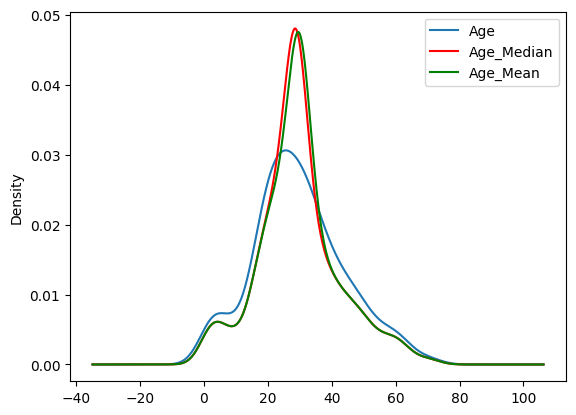

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind = 'kde',ax=ax)

# variable imputed with median
X_train['Age_Median'].plot(kind='kde',ax=ax, color='red')

# variable imputed with mean
X_train['Age_Mean'].plot(kind='kde',ax=ax, color='green')

# add legends
lines, lables  = ax.get_legend_handles_labels()
ax.legend(lines, lables, loc='best')

In [ ]:
X_train.cov()

,Age,Fare,Age_Median,Age_Mean,Fare_Median,Fare_Mean
Age,204.349513,71.512440,204.349513,204.349513,71.512440,71.512440
Fare,71.512440,2368.246832,58.986531,56.626587,2368.246832,2368.246832
Age_Median,204.349513,58.986531,161.989566,161.812625,58.986531,58.986531
Age_Mean,204.349513,56.626587,161.812625,161.812625,56.626587,56.626587
Fare_Median,71.512440,2368.246832,58.986531,56.626587,2368.246832,2368.246832
Fare_Mean,71.512440,2368.246832,58.986531,56.626587,2368.246832,2368.246832


In [ ]:
X_train.corr()

,Age,Fare,Age_Median,Age_Mean,Fare_Median,Fare_Mean
Age,1.000000,0.095814,1.000000,1.000000,0.095814,0.095814
Fare,0.095814,1.000000,0.095235,0.091475,1.000000,1.000000
Age_Median,1.000000,0.095235,1.000000,0.999454,0.095235,0.095235
Age_Mean,1.000000,0.091475,0.999454,1.000000,0.091475,0.091475
Fare_Median,0.095814,1.000000,0.095235,0.091475,1.000000,1.000000
Fare_Mean,0.095814,1.000000,0.095235,0.091475,1.000000,1.000000


<Axes: >

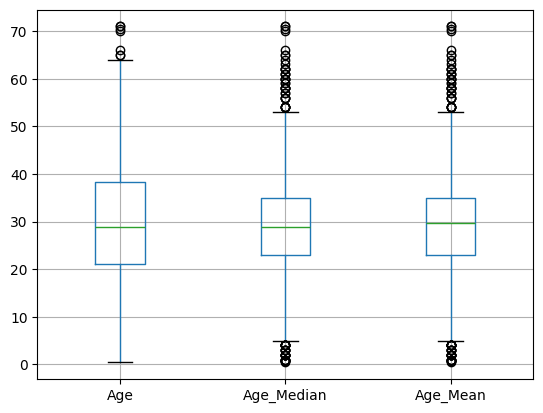

In [ ]:
X_train[['Age','Age_Median','Age_Mean']].boxplot()

Using Sklearn

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
from sklearn.impute import SimpleImputer
imputer1 = SimpleImputer(strategy = 'median')
imputer2 = SimpleImputer(strategy='mean')

In [ ]:
from sklearn.compose import ColumnTransformer
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [ ]:
trf.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])